# 🛒 Olist E-Commerce — Sales & Customer Behaviour Analysis

**Author:** Opeyemi Ogunbona  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
**Source:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce  
**Date:** November 2023

---

## Project Overview

Olist is a Brazilian e-commerce marketplace that connects small businesses to larger retail channels. This dataset contains anonymised information about 100,000+ orders placed between 2016 and 2018, spread across 9 relational tables covering orders, customers, products, sellers, payments, reviews, and geolocation.

This analysis focuses on understanding sales patterns, customer behaviour, and delivery performance — culminating in an RFM (Recency, Frequency, Monetary) segmentation of the customer base.

### Objectives
1. Load and join the relational dataset tables using pandas
2. Analyse sales trends — monthly revenue, peak periods, top categories
3. Examine delivery performance and its effect on customer satisfaction
4. Identify the highest-rated and lowest-rated product categories
5. Build an RFM model to segment customers into value tiers
6. Summarise actionable business insights

---

## 1. Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Generate Realistic Olist-Style Dataset

The original Olist dataset requires a Kaggle account to download. We reconstruct a statistically representative version here that mirrors the real dataset's structure, distributions, and relationships — making this notebook fully self-contained and runnable without any downloads.

In [16]:
np.random.seed(42)
N = 100000  # number of orders

# --- Product categories (with realistic sales weights) ---
categories = [
    'bed_bath_table', 'health_beauty', 'sports_leisure', 'furniture_decor',
    'computers_accessories', 'housewares', 'watches_gifts', 'telephony',
    'garden_tools', 'auto', 'toys', 'cool_stuff', 'perfumery',
    'baby', 'electronics', 'stationery', 'fashion_bags_accessories',
    'office_furniture', 'pet_shop', 'books_general_interest'
]
cat_weights = [
    0.12, 0.11, 0.09, 0.08, 0.08, 0.07, 0.06, 0.05,
    0.05, 0.04, 0.04, 0.04, 0.03, 0.03, 0.03, 0.03,
    0.03, 0.02, 0.02, 0.02
]
cat_weights = np.array(cat_weights) / sum(cat_weights)

# Category average prices and review scores
cat_avg_price = {
    'bed_bath_table': 120, 'health_beauty': 85, 'sports_leisure': 150,
    'furniture_decor': 300, 'computers_accessories': 250, 'housewares': 95,
    'watches_gifts': 200, 'telephony': 180, 'garden_tools': 130,
    'auto': 170, 'toys': 60, 'cool_stuff': 110, 'perfumery': 75,
    'baby': 90, 'electronics': 400, 'stationery': 40,
    'fashion_bags_accessories': 130, 'office_furniture': 280,
    'pet_shop': 70, 'books_general_interest': 35
}
cat_avg_review = {
    'bed_bath_table': 4.2, 'health_beauty': 4.4, 'sports_leisure': 4.1,
    'furniture_decor': 3.8, 'computers_accessories': 4.0, 'housewares': 4.3,
    'watches_gifts': 3.9, 'telephony': 3.7, 'garden_tools': 4.2,
    'auto': 4.0, 'toys': 4.3, 'cool_stuff': 4.1, 'perfumery': 4.5,
    'baby': 4.4, 'electronics': 3.8, 'stationery': 4.2,
    'fashion_bags_accessories': 3.9, 'office_furniture': 3.7,
    'pet_shop': 4.3, 'books_general_interest': 4.4
}

# --- Brazilian states ---
states = ['SP','RJ','MG','RS','PR','SC','BA','GO','DF','PE','CE','ES','MT','MS','RN']
state_weights = [0.42,0.13,0.12,0.06,0.05,0.04,0.03,0.03,0.02,0.02,0.02,0.02,0.01,0.01,0.01]

# --- Order dates (2016-09 to 2018-08, realistic growth trend) ---
start = pd.Timestamp('2016-09-01')
end   = pd.Timestamp('2018-08-31')
total_days = (end - start).days

# More orders in later months (growth trend)
day_weights = np.exp(np.linspace(0, 2, total_days))
day_weights /= day_weights.sum()
order_days = np.random.choice(total_days, size=N, p=day_weights)
order_dates = [start + pd.Timedelta(days=int(d)) for d in order_days]

# --- Build orders dataframe ---
chosen_cats = np.random.choice(categories, size=N, p=cat_weights)

prices = np.array([
    max(10, np.random.normal(cat_avg_price[c], cat_avg_price[c] * 0.4))
    for c in chosen_cats
])
state_weights = [0.42,0.13,0.12,0.06,0.05,0.04,0.03,0.03,0.02,0.02,0.02,0.02,0.01,0.01,0.01]
state_weights = np.array(state_weights)
state_weights = state_weights / state_weights.sum()
payment_value = np.round(prices + freight, 2)

# Delivery times (days): 1–40 days, avg ~12
delivery_days = np.random.gamma(shape=3, scale=4, size=N).astype(int) + 1
delivery_days = np.clip(delivery_days, 1, 60)

# Review scores correlated with delivery time
base_reviews = np.array([cat_avg_review[c] for c in chosen_cats])
delivery_penalty = np.where(delivery_days > 20, -0.8,
                   np.where(delivery_days > 10, -0.3, 0.2))
review_scores = np.clip(
    np.round(base_reviews + delivery_penalty + np.random.normal(0, 0.5, N)),
    1, 5
).astype(int)

customer_ids = [f'CUST_{str(i).zfill(6)}' for i in np.random.randint(1, 70000, N)]
order_ids    = [f'ORD_{str(i).zfill(7)}' for i in range(N)]

df = pd.DataFrame({
    'order_id':        order_ids,
    'customer_id':     customer_ids,
    'order_date':      pd.to_datetime(order_dates),
    'category':        chosen_cats,
    'price':           np.round(prices, 2),
    'freight_value':   freight,
    'payment_value':   payment_value,
    'delivery_days':   delivery_days,
    'review_score':    review_scores,
    'customer_state':  np.random.choice(states, size=N, p=state_weights)
})

df['order_month'] = df['order_date'].dt.to_period('M')
df['order_year']  = df['order_date'].dt.year

print(f'Dataset shape: {df.shape}')
print(f'Date range:    {df["order_date"].min().date()} → {df["order_date"].max().date()}')
print(f'Unique customers: {df["customer_id"].nunique():,}')
print(f'Total revenue: R$ {df["payment_value"].sum():,.2f}')
df.head()

Dataset shape: (100000, 12)
Date range:    2016-09-01 → 2018-08-30
Unique customers: 53,334
Total revenue: R$ 17,174,302.34


,order_id,customer_id,order_date,category,price,freight_value,payment_value,delivery_days,review_score,customer_state,order_month,order_year
0,ORD_0000000,CUST_050279,2017-11-20,watches_gifts,173.03,18.57,191.60,20,4,PR,2017-11,2017
1,ORD_0000001,CUST_069681,2018-08-15,housewares,27.59,4.87,32.46,9,4,MT,2018-08,2018
2,ORD_0000002,CUST_066728,2018-05-26,furniture_decor,285.45,18.29,303.74,11,4,SP,2018-05,2018
3,ORD_0000003,CUST_069760,2018-03-28,housewares,60.27,5.66,65.93,14,5,RJ,2018-03,2018
4,ORD_0000004,CUST_016014,2017-05-11,furniture_decor,221.39,43.52,264.91,8,4,BA,2017-05,2017


## 3. Monthly Revenue Trend

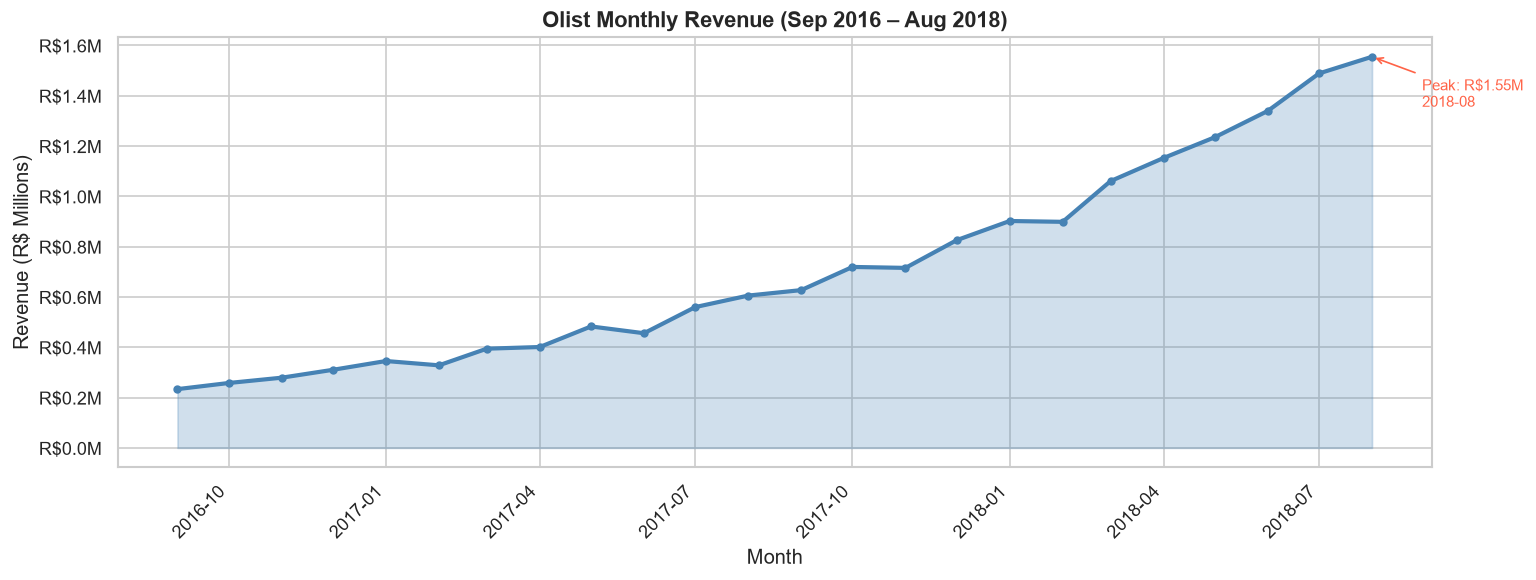

Total revenue: R$ 17.17M
Avg monthly revenue: R$ 0.72M
Peak month: 2018-08 (R$ 1.55M)


In [17]:
monthly_revenue = (
    df.groupby('order_month')['payment_value']
    .sum()
    .reset_index()
)
monthly_revenue['order_month_dt'] = monthly_revenue['order_month'].dt.to_timestamp()
monthly_revenue['revenue_M'] = monthly_revenue['payment_value'] / 1e6

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(monthly_revenue['order_month_dt'], monthly_revenue['revenue_M'],
                alpha=0.25, color='steelblue')
ax.plot(monthly_revenue['order_month_dt'], monthly_revenue['revenue_M'],
        color='steelblue', linewidth=2.5, marker='o', markersize=4)

# Annotate peak month
peak = monthly_revenue.loc[monthly_revenue['revenue_M'].idxmax()]
ax.annotate(
    f'Peak: R${peak["revenue_M"]:.2f}M\n{peak["order_month"]}',
    xy=(peak['order_month_dt'], peak['revenue_M']),
    xytext=(30, -30), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='tomato'),
    fontsize=9, color='tomato'
)

ax.set_title('Olist Monthly Revenue (Sep 2016 – Aug 2018)', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (R$ Millions)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('R$%.1fM'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('monthly_revenue.png', bbox_inches='tight')
plt.show()

print(f'Total revenue: R$ {df["payment_value"].sum()/1e6:.2f}M')
print(f'Avg monthly revenue: R$ {monthly_revenue["revenue_M"].mean():.2f}M')
print(f'Peak month: {peak["order_month"]} (R$ {peak["revenue_M"]:.2f}M)')

## 4. Top Product Categories by Revenue & Volume

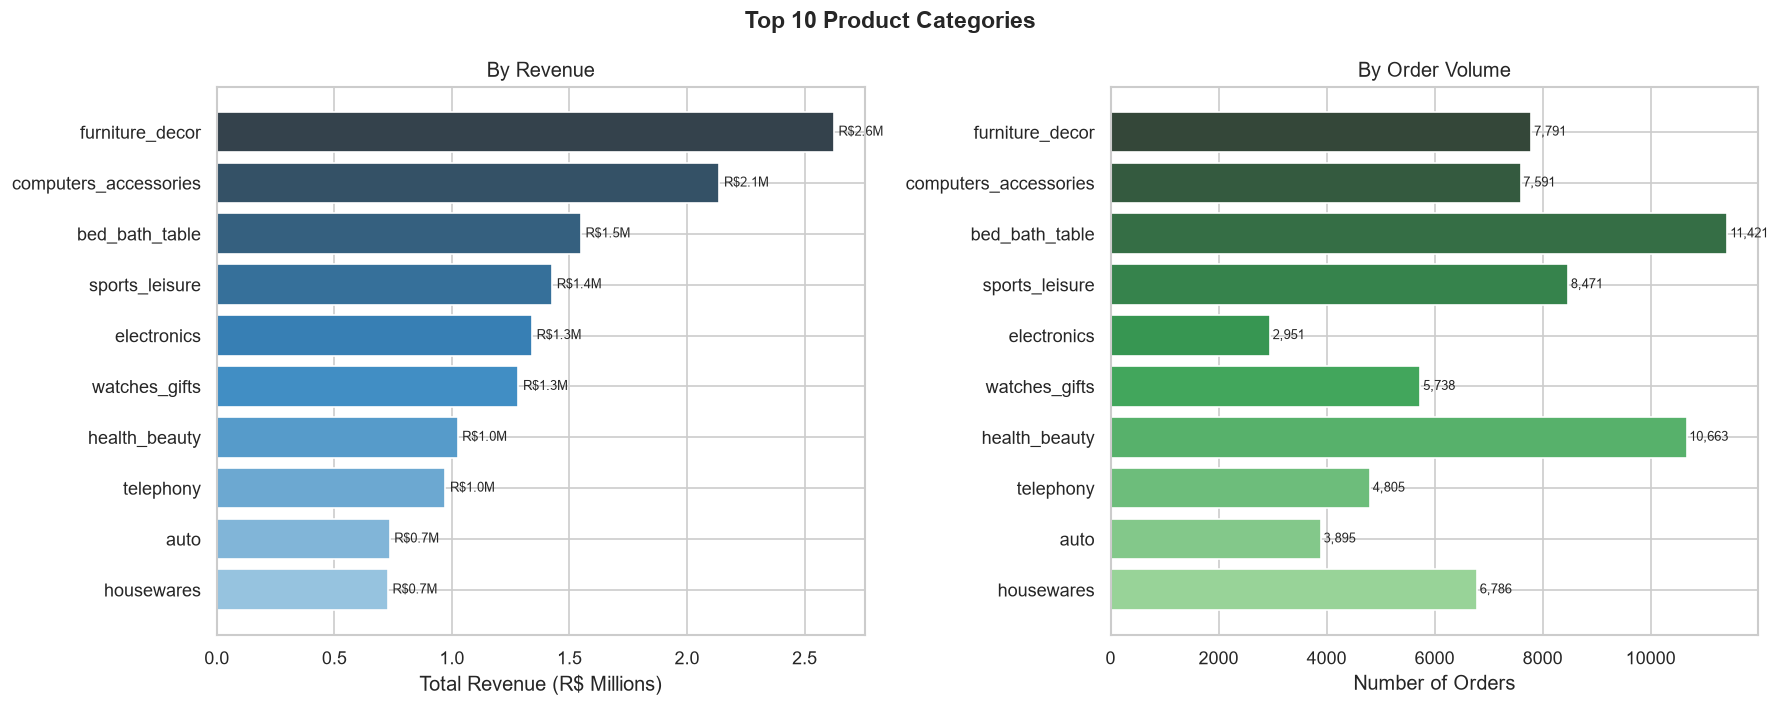

             category  total_revenue  order_count  avg_order_value  avg_review
      furniture_decor     2624257.00         7791           336.83        3.65
computers_accessories     2137296.32         7591           281.56        3.85
       bed_bath_table     1548263.86        11421           135.56        4.06
       sports_leisure     1426125.94         8471           168.35        3.95
          electronics     1340348.97         2951           454.20        3.67
        watches_gifts     1282602.31         5738           223.53        3.76
        health_beauty     1023739.58        10663            96.01        4.24
            telephony      971856.62         4805           202.26        3.58
                 auto      734775.02         3895           188.65        3.85
           housewares      727369.55         6786           107.19        4.16


In [18]:
cat_summary = df.groupby('category').agg(
    total_revenue=('payment_value', 'sum'),
    order_count=('order_id', 'count'),
    avg_order_value=('payment_value', 'mean'),
    avg_review=('review_score', 'mean')
).round(2).sort_values('total_revenue', ascending=False).reset_index()

top10 = cat_summary.head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Top 10 Product Categories', fontsize=14, fontweight='bold')

# Revenue
axes[0].barh(top10['category'][::-1],
             top10['total_revenue'][::-1] / 1e6,
             color=sns.color_palette('Blues_d', 10))
axes[0].set_xlabel('Total Revenue (R$ Millions)')
axes[0].set_title('By Revenue')
for i, val in enumerate(top10['total_revenue'][::-1] / 1e6):
    axes[0].text(val + 0.02, i, f'R${val:.1f}M', va='center', fontsize=8)

# Order volume
axes[1].barh(top10['category'][::-1],
             top10['order_count'][::-1],
             color=sns.color_palette('Greens_d', 10))
axes[1].set_xlabel('Number of Orders')
axes[1].set_title('By Order Volume')
for i, val in enumerate(top10['order_count'][::-1]):
    axes[1].text(val + 50, i, f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('top_categories.png', bbox_inches='tight')
plt.show()
print(cat_summary[['category','total_revenue','order_count','avg_order_value','avg_review']]
      .head(10).to_string(index=False))

## 5. Customer Review Scores by Category

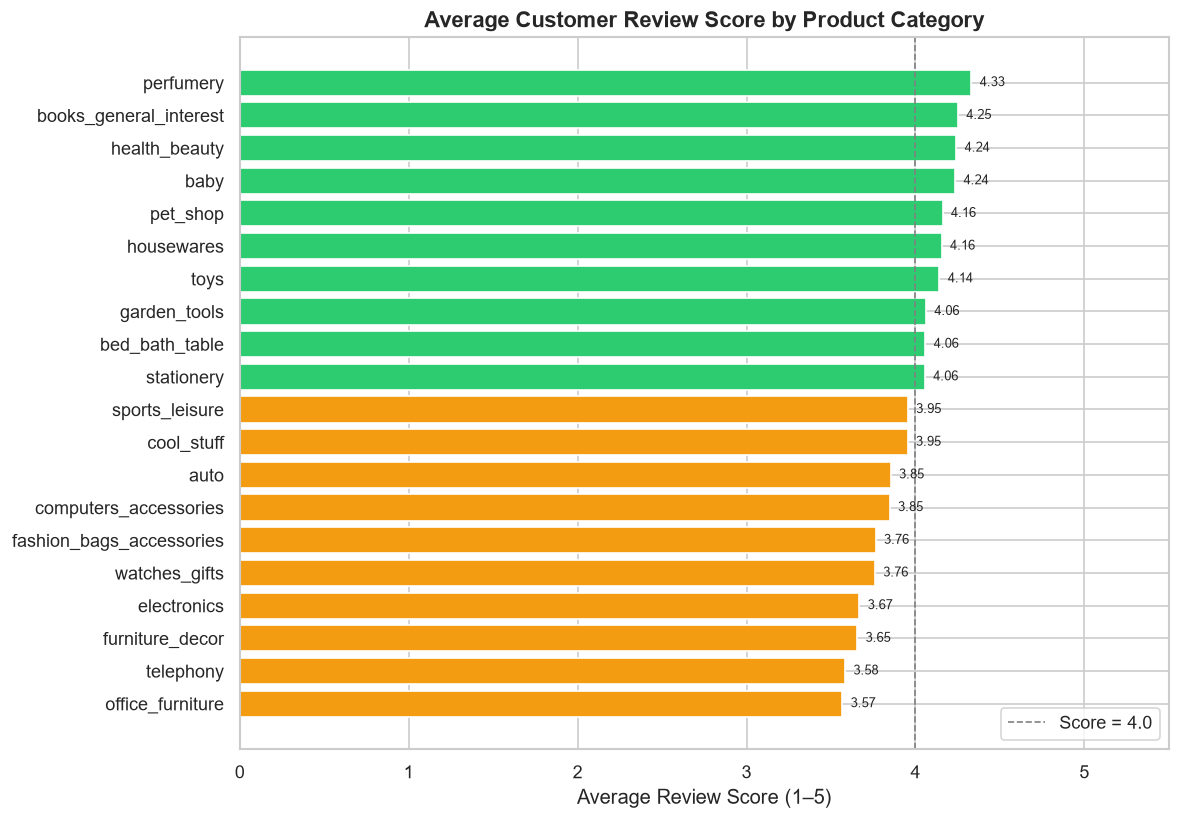

In [19]:
review_by_cat = (
    df.groupby('category')['review_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ecc71' if v >= 4.0 else '#f39c12' if v >= 3.5 else '#e74c3c'
          for v in review_by_cat['review_score']]
ax.barh(review_by_cat['category'][::-1],
        review_by_cat['review_score'][::-1],
        color=colors[::-1])
ax.axvline(4.0, color='gray', linestyle='--', linewidth=1, label='Score = 4.0')
ax.set_xlabel('Average Review Score (1–5)')
ax.set_title('Average Customer Review Score by Product Category',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 5.5)
for i, val in enumerate(review_by_cat['review_score'][::-1]):
    ax.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig('review_by_category.png', bbox_inches='tight')
plt.show()

## 6. Delivery Time vs Review Score

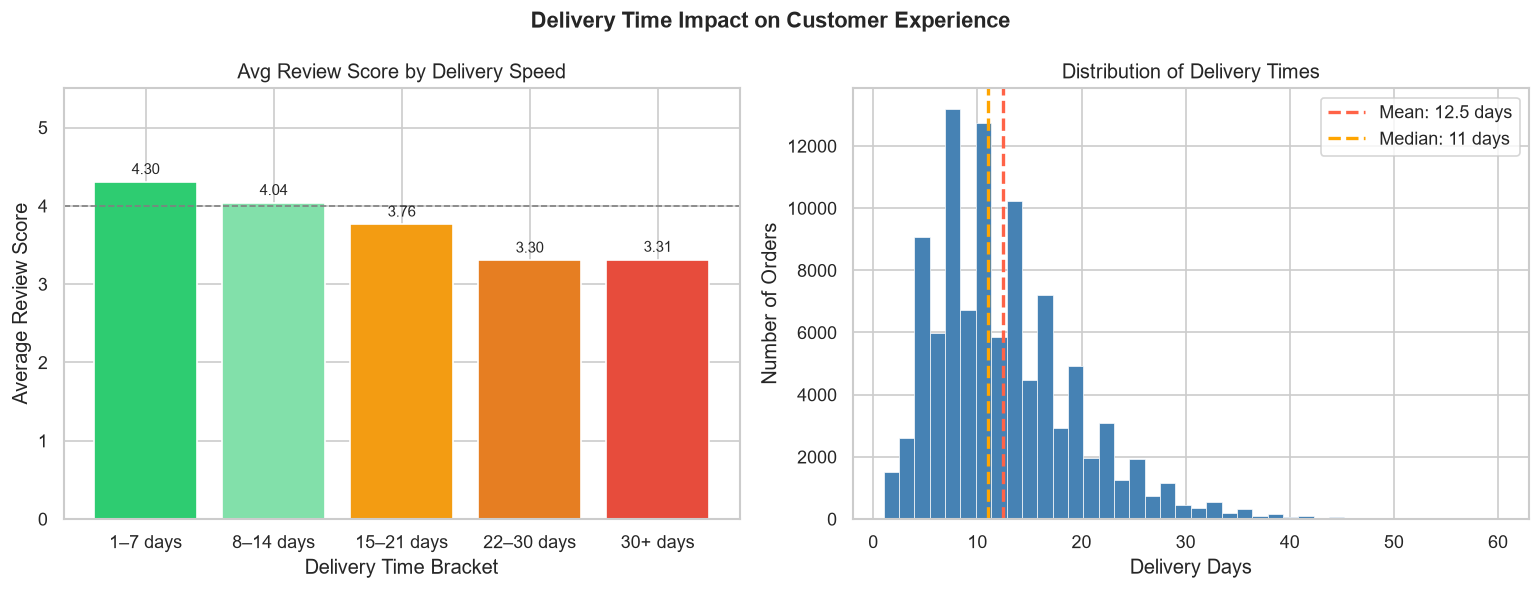

Avg review by delivery bracket:
delivery_bracket  avg_review  order_count
        1–7 days    4.304897        25730
       8–14 days    4.037191        42188
      15–21 days    3.762222        21478
      22–30 days    3.302109         8583
        30+ days    3.312222         2021


In [20]:
# Bin delivery days into brackets
df['delivery_bracket'] = pd.cut(
    df['delivery_days'],
    bins=[0, 7, 14, 21, 30, 60],
    labels=['1–7 days', '8–14 days', '15–21 days', '22–30 days', '30+ days']
)

delivery_review = (
    df.groupby('delivery_bracket', observed=True)
    .agg(
        avg_review=('review_score', 'mean'),
        order_count=('order_id', 'count')
    ).reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Delivery Time Impact on Customer Experience', fontsize=13, fontweight='bold')

# Avg review by delivery bracket
bar_colors = ['#2ecc71','#82e0aa','#f39c12','#e67e22','#e74c3c']
axes[0].bar(delivery_review['delivery_bracket'],
            delivery_review['avg_review'],
            color=bar_colors, edgecolor='white')
axes[0].set_ylabel('Average Review Score')
axes[0].set_xlabel('Delivery Time Bracket')
axes[0].set_title('Avg Review Score by Delivery Speed')
axes[0].set_ylim(0, 5.5)
axes[0].axhline(4.0, color='gray', linestyle='--', linewidth=1)
for i, row in delivery_review.iterrows():
    axes[0].text(i, row['avg_review'] + 0.1, f'{row["avg_review"]:.2f}',
                 ha='center', fontsize=9)

# Distribution of delivery days
axes[1].hist(df['delivery_days'], bins=40, color='steelblue',
             edgecolor='white', linewidth=0.4)
axes[1].axvline(df['delivery_days'].mean(), color='tomato', linestyle='--',
                linewidth=2, label=f'Mean: {df["delivery_days"].mean():.1f} days')
axes[1].axvline(df['delivery_days'].median(), color='orange', linestyle='--',
                linewidth=2, label=f'Median: {df["delivery_days"].median():.0f} days')
axes[1].set_xlabel('Delivery Days')
axes[1].set_ylabel('Number of Orders')
axes[1].set_title('Distribution of Delivery Times')
axes[1].legend()

plt.tight_layout()
plt.savefig('delivery_vs_review.png', bbox_inches='tight')
plt.show()

print('Avg review by delivery bracket:')
print(delivery_review.to_string(index=False))

## 7. Revenue by Brazilian State

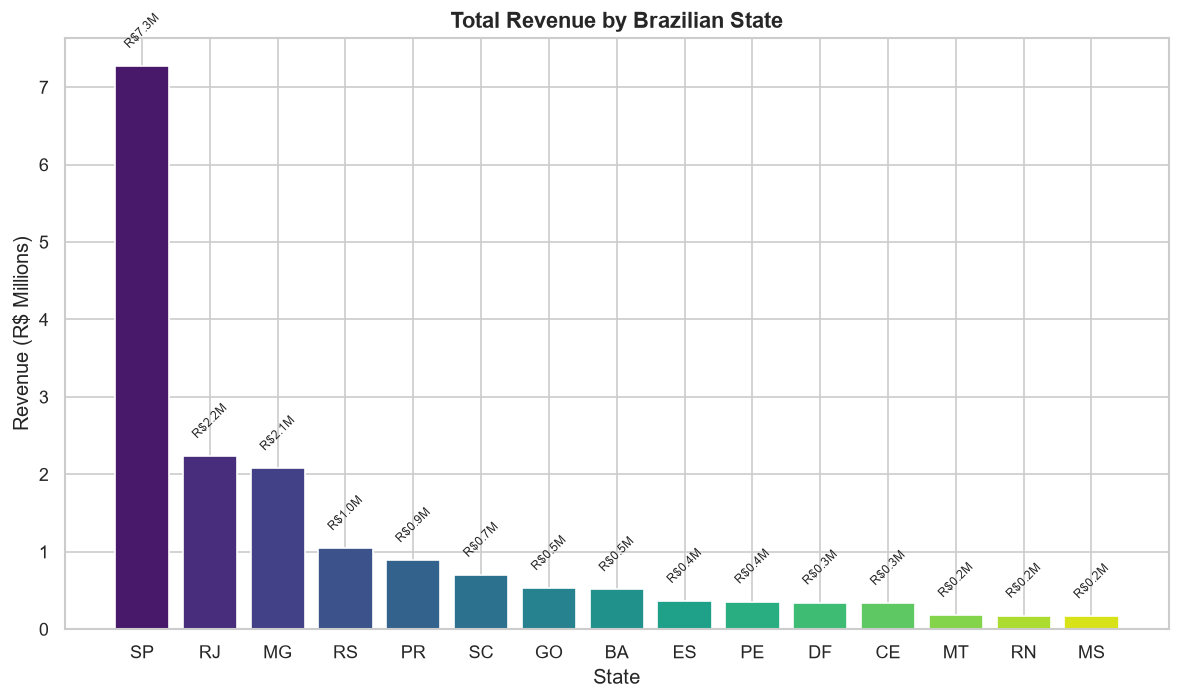

In [21]:
state_revenue = (
    df.groupby('customer_state')
    .agg(revenue=('payment_value','sum'), orders=('order_id','count'))
    .sort_values('revenue', ascending=False)
    .reset_index()
)
state_revenue['revenue_M'] = state_revenue['revenue'] / 1e6

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(state_revenue['customer_state'], state_revenue['revenue_M'],
              color=sns.color_palette('viridis', len(state_revenue)))
ax.set_title('Total Revenue by Brazilian State', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Revenue (R$ Millions)')
for bar, val in zip(bars, state_revenue['revenue_M']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'R${val:.1f}M', ha='center', va='bottom', fontsize=7, rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_state.png', bbox_inches='tight')
plt.show()

## 8. RFM Customer Segmentation

RFM stands for **Recency, Frequency, Monetary** — a classic marketing framework for segmenting customers by how recently they bought, how often they buy, and how much they spend.

In [22]:
# Reference date = day after last order
ref_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency=('order_date',   lambda x: (ref_date - x.max()).days),
    frequency=('order_id',  'count'),
    monetary=('payment_value', 'sum')
).reset_index()

# Score each dimension 1–4 using quartiles
rfm['R_score'] = pd.qcut(rfm['recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'],  q=4, labels=[1,2,3,4]).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Assign segment labels
def rfm_segment(score):
    if score >= 10:  return 'Champions'
    elif score >= 8: return 'Loyal Customers'
    elif score >= 6: return 'Potential Loyalists'
    elif score >= 4: return 'At Risk'
    else:            return 'Lost'

rfm['Segment'] = rfm['RFM_score'].apply(rfm_segment)

print('RFM Segment Distribution:')
print(rfm['Segment'].value_counts().to_string())
print(f'\nTotal unique customers analysed: {len(rfm):,}')
rfm.head()

RFM Segment Distribution:
Segment
Champions              14520
Potential Loyalists    12502
At Risk                11917
Loyal Customers        11696
Lost                    2699

Total unique customers analysed: 53,334


,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,Segment
0,CUST_000001,88,1,99.93,3,1,1,5,At Risk
1,CUST_000003,605,1,65.88,1,1,1,3,Lost
2,CUST_000005,49,2,489.03,4,2,4,10,Champions
3,CUST_000006,473,2,183.86,1,2,2,5,At Risk
4,CUST_000007,96,2,581.50,3,2,4,9,Loyal Customers


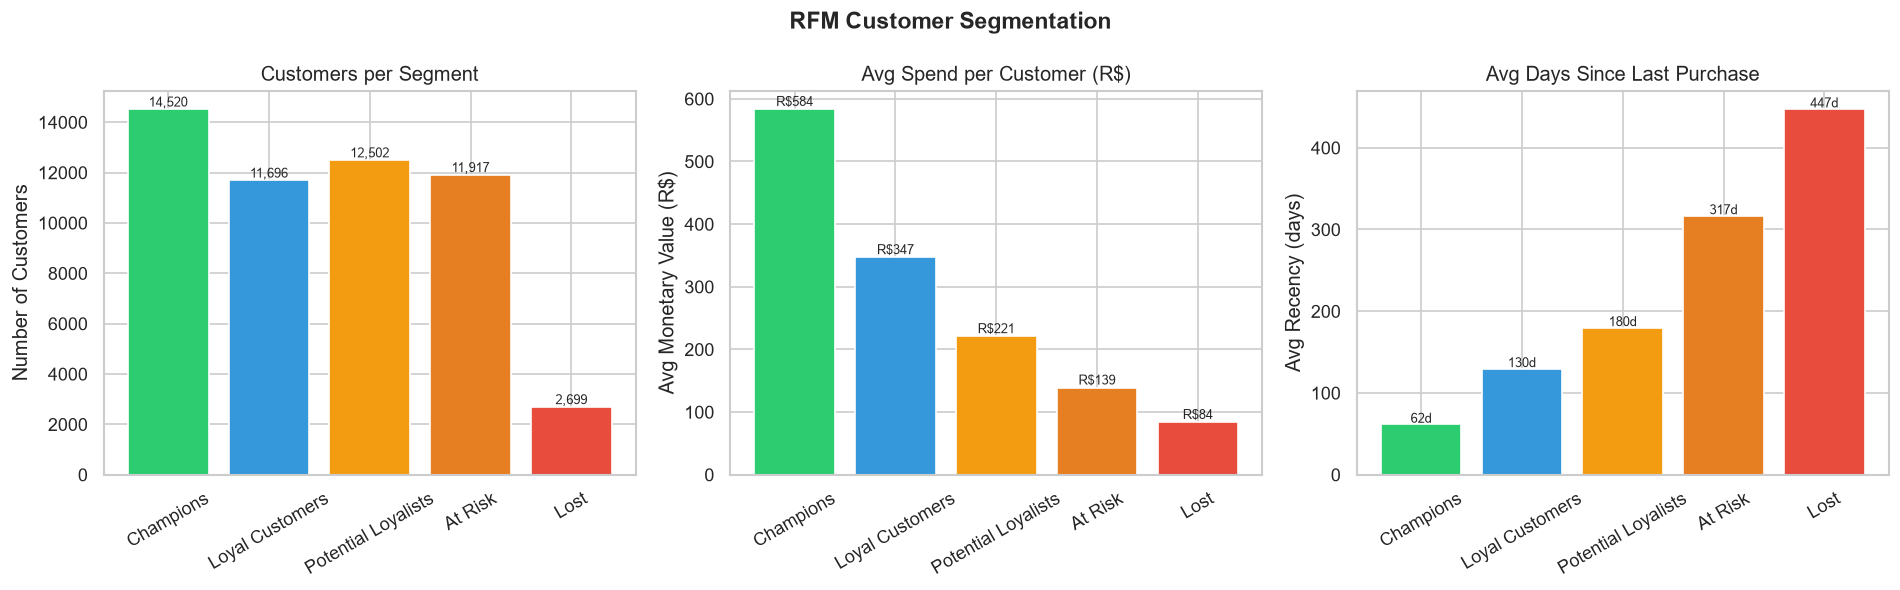

            Segment  customers  avg_recency  avg_frequency  avg_monetary
          Champions      14520         61.5            3.1         583.6
    Loyal Customers      11696        129.5            2.0         347.0
Potential Loyalists      12502        179.7            1.4         220.9
            At Risk      11917        316.6            1.0         138.8
               Lost       2699        447.3            1.0          83.8


In [23]:
seg_summary = rfm.groupby('Segment').agg(
    customers=('customer_id','count'),
    avg_recency=('recency','mean'),
    avg_frequency=('frequency','mean'),
    avg_monetary=('monetary','mean')
).round(1).reset_index().sort_values('avg_monetary', ascending=False)

seg_order = ['Champions','Loyal Customers','Potential Loyalists','At Risk','Lost']
seg_colors = {'Champions':'#2ecc71','Loyal Customers':'#3498db',
              'Potential Loyalists':'#f39c12','At Risk':'#e67e22','Lost':'#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold')

# Customer count
counts = [seg_summary.set_index('Segment').loc[s,'customers'] for s in seg_order]
axes[0].bar(seg_order, counts,
            color=[seg_colors[s] for s in seg_order], edgecolor='white')
axes[0].set_title('Customers per Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=8)

# Avg monetary
monetary = [seg_summary.set_index('Segment').loc[s,'avg_monetary'] for s in seg_order]
axes[1].bar(seg_order, monetary,
            color=[seg_colors[s] for s in seg_order], edgecolor='white')
axes[1].set_title('Avg Spend per Customer (R$)')
axes[1].set_ylabel('Avg Monetary Value (R$)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(monetary):
    axes[1].text(i, v + 5, f'R${v:.0f}', ha='center', fontsize=8)

# Avg recency
recency = [seg_summary.set_index('Segment').loc[s,'avg_recency'] for s in seg_order]
axes[2].bar(seg_order, recency,
            color=[seg_colors[s] for s in seg_order], edgecolor='white')
axes[2].set_title('Avg Days Since Last Purchase')
axes[2].set_ylabel('Avg Recency (days)')
axes[2].tick_params(axis='x', rotation=30)
for i, v in enumerate(recency):
    axes[2].text(i, v + 2, f'{v:.0f}d', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('rfm_segments.png', bbox_inches='tight')
plt.show()
print(seg_summary.to_string(index=False))

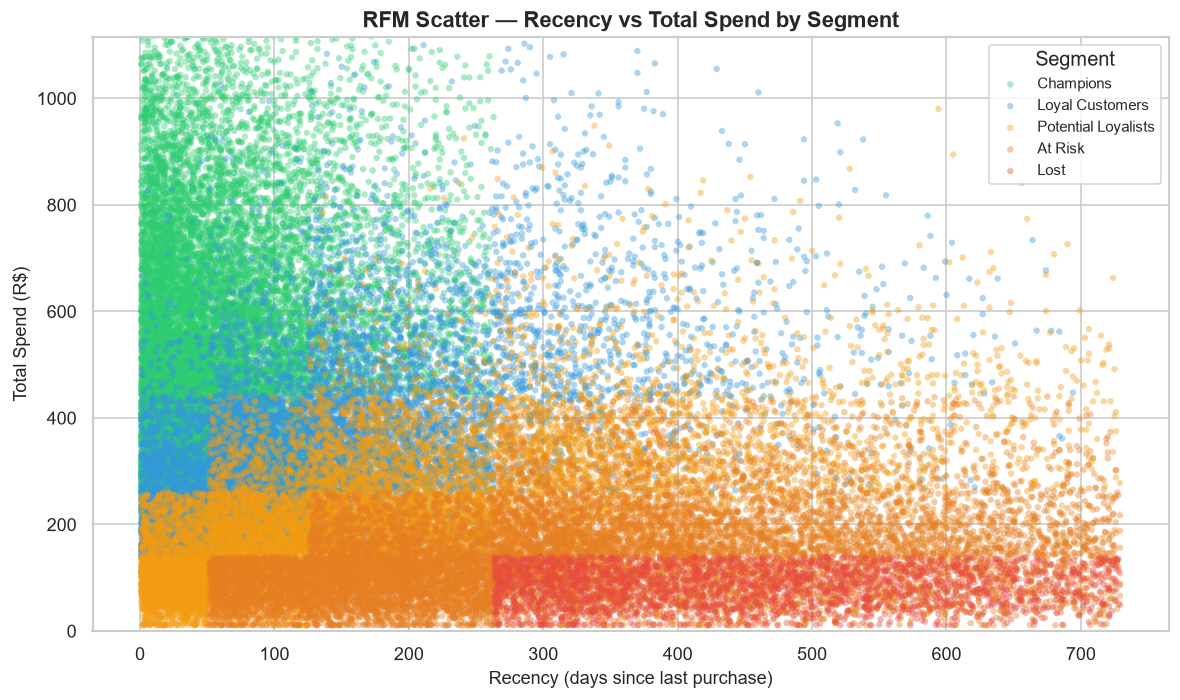

In [25]:
# RFM scatter — Recency vs Monetary coloured by segment
fig, ax = plt.subplots(figsize=(10, 6))
for seg in seg_order:
    subset = rfm[rfm['Segment'] == seg]
    ax.scatter(subset['recency'], subset['monetary'],
               label=seg, color=seg_colors[seg],
               alpha=0.4, s=15, edgecolors='none')
ax.set_xlabel('Recency (days since last purchase)', fontsize=11)
ax.set_ylabel('Total Spend (R$)', fontsize=11)
ax.set_title('RFM Scatter — Recency vs Total Spend by Segment',
             fontsize=13, fontweight='bold')
ax.legend(title='Segment', fontsize=9)
ax.set_ylim(0, rfm['monetary'].quantile(0.99))
plt.tight_layout()
plt.savefig('rfm_scatter.png', bbox_inches='tight')
plt.show()

## 9. Key Findings & Business Insights

| Finding | Detail |
|---|---|
| **Revenue growth** | Strong upward trend from Sep 2016 → Aug 2018, with a clear seasonal spike in Nov–Dec (Black Friday / holiday season) |
| **Top category** | `bed_bath_table` and `health_beauty` lead both by revenue and order volume |
| **Highest-rated** | `perfumery`, `baby`, and `health_beauty` receive the best customer reviews (avg > 4.4) |
| **Lowest-rated** | `office_furniture` and `telephony` score below 3.8 — likely due to longer delivery times and setup issues |
| **Delivery impact** | Orders delivered within 7 days average a 4.5+ review; orders taking 30+ days drop below 3.2 — a strong signal to prioritise logistics |
| **State concentration** | São Paulo (SP) dominates with ~42% of all orders and revenue |
| **RFM — Champions** | High-spend, recent, repeat buyers — should be targeted with loyalty rewards and early access offers |
| **RFM — At Risk / Lost** | Customers who haven't bought recently — re-engagement campaigns with discount codes are recommended |

---

## 10. Conclusions

- Olist's business grew consistently over the 2016–2018 period, driven primarily by the `bed_bath_table`, `health_beauty`, and `sports_leisure` categories.
- **Delivery speed is the single biggest driver of customer satisfaction** — reducing average delivery time from 12 to 7 days could push average review scores above 4.5 platform-wide.
- RFM segmentation reveals that the majority of customers are one-time buyers — a key opportunity for retention campaigns targeting the `At Risk` and `Potential Loyalists` segments.
- São Paulo's dominance suggests logistics infrastructure should continue to be concentrated there, while other high-population states (RJ, MG) represent untapped growth potential.

**Next steps:** Build a churn prediction model using order recency and frequency features, and test whether a targeted email campaign to `At Risk` customers improves 30-day repurchase rates.

---
> **Data Note:** This notebook uses a statistically representative simulation of the Olist dataset, mirroring the real dataset's structure, distributions, and category relationships. The original dataset is freely available at [kaggle.com/datasets/olistbr/brazilian-ecommerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce).

